<a href="https://colab.research.google.com/github/Sonia151202/Sonia/blob/main/news%20article%20classification%20and%20summarization%20code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install textblob
!pip install vaderSentiment
!pip install rouge-score
!pip install --upgrade torch torchvision torchaudio
!pip install torch==2.0.0
!pip install transformers==4.30.0
!pip install textblob==3.0.0  # or another stable version

# Download the spaCy model first
!python -m spacy download en_core_web_sm
# Then install spaCyTextBlob
!pip install spacytextblob
!pip install spacytextblob==0.1.7


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=e82d3e1e56ca2f45d6136b8a214848a2ba1b2271e762ca5b6dbce04585b2d9b0
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'


In [ ]:

nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.data.path.append('C:\\Users\\91849\\AppData\\Roaming\\nltk_data')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# URL of news articles
base_url = "https://www.thestar.com.my/news/latest/"
responses = []
# Loop over pages 1 to 25
for page_num in range(1, 26):
    url = f"{base_url}?pgno={page_num}#latest"
    print(f"Scraping page: {url}")
    response = requests.get(url)

    if response.status_code == 200:
        print(f"Successfully fetched page {page_num}")
        responses.append(response.content)
    else:
        print(f"Failed to fetch the page {page_num}. Status code: {response.status_code}")

print(f"Fetched {len(responses)} pages.")
# Extracting the headlines and URLs
headlines_list = []
urls_list = []
for response in responses:
    soup = BeautifulSoup(response, "html.parser")

    headlines = soup.find_all("h2", class_="f18")

    for headline in headlines:
        headlines_list.append(headline.get_text(strip=True))
        link = headline.find("a")
        if link and link.get("href"):
            urls_list.append(link.get("href"))
        else:
            urls_list.append(None)
            # Creating a DataFrame
df = pd.DataFrame({
    "Headline": headlines_list,
    "URL": urls_list
})
# Extracting article content
def get_article_content(url):
    try:
        article_response = requests.get(url)

        if article_response.status_code == 200:
            article_soup = BeautifulSoup(article_response.content, "html.parser")
            article_content = article_soup.find("div", class_="row content-holder story-wrapper")

            if article_content:
                paragraphs = article_content.find_all("p")
                article_text = " ".join([para.get_text(strip=True) for para in paragraphs])
                return article_text
            else:
                return None
        else:
            print(f"Failed to fetch content for {url}. Status code: {article_response.status_code}")
            return None
    except Exception as e:
        print(f"Error fetching content for {url}: {e}")
        return None
        # Adding article content to the DataFrame
df["Article Content"] = df["URL"].apply(lambda url: get_article_content(url) if url else None)

Scraping page: https://www.thestar.com.my/news/latest/?pgno=1#latest
Successfully fetched page 1
Scraping page: https://www.thestar.com.my/news/latest/?pgno=2#latest
Successfully fetched page 2
Scraping page: https://www.thestar.com.my/news/latest/?pgno=3#latest
Successfully fetched page 3
Scraping page: https://www.thestar.com.my/news/latest/?pgno=4#latest
Successfully fetched page 4
Scraping page: https://www.thestar.com.my/news/latest/?pgno=5#latest
Successfully fetched page 5
Scraping page: https://www.thestar.com.my/news/latest/?pgno=6#latest
Successfully fetched page 6
Scraping page: https://www.thestar.com.my/news/latest/?pgno=7#latest
Successfully fetched page 7
Scraping page: https://www.thestar.com.my/news/latest/?pgno=8#latest
Successfully fetched page 8
Scraping page: https://www.thestar.com.my/news/latest/?pgno=9#latest
Successfully fetched page 9
Scraping page: https://www.thestar.com.my/news/latest/?pgno=10#latest
Successfully fetched page 10
Scraping page: https://www.t

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Headline         500 non-null    object
 1   URL              500 non-null    object
 2   Article Content  500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB


,Headline,URL,Article Content
0,Russia says it thwarts Ukrainian plots to kill...,https://www.thestar.com.my/news/world/2024/12/...,"Thursday, 26 Dec 2024 MOSCOW (Reuters) -Russia..."
1,"Asian currencies struggle, stocks mostly lower...",https://www.thestar.com.my/business/business-n...,"Thursday, 26 Dec 2024 Emerging Asian currencie..."
2,Alleged burglars entered Holland Road home via...,https://www.thestar.com.my/aseanplus/aseanplus...,"Thursday, 26 Dec 2024 Police taking Feng Yunlo..."
3,Cambodia court jails opposition party leader S...,https://www.thestar.com.my/aseanplus/aseanplus...,"Thursday, 26 Dec 2024 PHNOM PENH: A court in C..."
4,Property sector showing signs of bottoming out,https://www.thestar.com.my/business/business-n...,"Thursday, 26 Dec 2024 A view of a property pro..."


In [ ]:
# Preprocessing text content (without stopword removal and lemmatization)
def clean_text_without_stopwords_and_lemmatization(text):
    if not text:
        return None
    # Remove non-alphabetical characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the cleaning function to each row of the 'Article Content' column
df['Preprocessed Article Content Without Stopwords'] = df['Article Content'].apply(clean_text_without_stopwords_and_lemmatization)


In [ ]:
# Define the ROUGE scorer
from rouge_score import rouge_scorer # Import the rouge_scorer module

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Function to generate a reference summary using NLTK (extractive summary)
def generate_nltk_reference_summary(article_text):
    if not article_text:
        return None
    # Tokenize the article into sentences
    sentences = nltk.sent_tokenize(article_text)
    # We'll simply use the first 3 sentences as the reference (you can adjust this strategy)
    reference_summary = ' '.join(sentences[:3])  # You can modify how many sentences to use
    return reference_summary

# Step 1: Generate the reference summaries using NLTK for each article in the 'Article Content' column
df['Reference Summary'] = df['Preprocessed Article Content Without Stopwords'].apply(generate_nltk_reference_summary)

In [ ]:
# Load the GPT-2 tokenizer and model
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2")

# Set the padding token to the eos_token
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # Set pad_token to eos_token

def summarize_with_gpt2(text):
    # Check if text is None and return None if it is
    if text is None:
        return None

    # Preprocess the text if necessary (e.g., adding a prompt)
    input_text = "Summarize: " + text

    # Tokenize the input text (this will pad the sequence if necessary)
    inputs = gpt2_tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True, padding=True)

    # Generate summary (using max_new_tokens to control output length)
    summary_ids = gpt2_model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=50,  # Generate only a maximum of 50 new tokens
        num_return_sequences=1,
        early_stopping=True
    )

    # Decode the generated summary
    summary = gpt2_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary



/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# Assuming 'df' is your DataFrame and 'Preprocessed Article Content Without Stopwords' is the column you want to summarize
df['GPT-2 Summary'] = df['Preprocessed Article Content Without Stopwords'].apply(summarize_with_gpt2)

# Check the first few rows of the DataFrame with the generated summaries
print(df[['Preprocessed Article Content Without Stopwords', 'GPT-2 Summary']].head())

df.info()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

      Preprocessed Article Content Without Stopwords  \
0  Thursday Dec MOSCOW Reuters Russias Federal Se...   
1  Thursday Dec Emerging Asian currencies were mo...   
2  Thursday Dec Police taking Feng Yunlong left a...   
3  Thursday Dec PHNOM PENH A court in Cambodia se...   
4  Thursday Dec A view of a property project unde...   

                                       GPT-2 Summary  
0  Summarize: Thursday Dec MOSCOW Reuters Russias...  
1  Summarize: Thursday Dec Emerging Asian currenc...  
2  Summarize: Thursday Dec Police taking Feng Yun...  
3  Summarize: Thursday Dec PHNOM PENH A court in ...  
4  Summarize: Thursday Dec A view of a property p...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   Headline                                        500 non-null    object
 

In [ ]:
# Function to calculate ROUGE scores for each row
def calculate_rouge_scores(row):
    reference = row['Reference Summary']
    generated_summary = row['GPT-2 Summary']

    # Check if either reference or generated_summary is None
    if reference is None or generated_summary is None:
        return {'rouge1': None, 'rouge2': None, 'rougeL': None}  # Return a dictionary with None values

    # Calculate ROUGE scores if both are not None
    scores = scorer.score(reference, generated_summary)

    return scores

# Apply the function to calculate ROUGE scores for each row and store in a new column
df['ROUGE Scores'] = df.apply(calculate_rouge_scores, axis=1)

# If you want to separate ROUGE scores into specific columns (e.g., rouge1, rouge2, and rougeL), you can do this:
df['ROUGE1'] = df['ROUGE Scores'].apply(lambda x: x['rouge1'].fmeasure if x['rouge1'] else None)  # Handle None values
df['ROUGE2'] = df['ROUGE Scores'].apply(lambda x: x['rouge2'].fmeasure if x['rouge2'] else None)  # Handle None values
df['ROUGEL'] = df['ROUGE Scores'].apply(lambda x: x['rougeL'].fmeasure if x['rougeL'] else None)  # Handle None values

# Calculate the average ROUGE scores for T5, ignoring None values
average_rouge1 = df['ROUGE1'].dropna().mean()
average_rouge2 = df['ROUGE2'].dropna().mean()
average_rougel = df['ROUGEL'].dropna().mean()

# Print the average ROUGE scores
print(f"Average ROUGE-1: {average_rouge1:.4f}")
print(f"Average ROUGE-2: {average_rouge2:.4f}")
print(f"Average ROUGE-L: {average_rougel:.4f}")


Average ROUGE-1: 0.8891
Average ROUGE-2: 0.8811
Average ROUGE-L: 0.8863


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Headline                                        500 non-null    object 
 1   URL                                             500 non-null    object 
 2   Article Content                                 500 non-null    object 
 3   Preprocessed Article Content Without Stopwords  500 non-null    object 
 4   Reference Summary                               500 non-null    object 
 5   GPT-2 Summary                                   500 non-null    object 
 6   ROUGE Scores                                    500 non-null    object 
 7   ROUGE1                                          500 non-null    float64
 8   ROUGE2                                          500 non-null    float64
 9   ROUGEL                                     

In [ ]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # Import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_with_vader(text):
    sentiment_score = analyzer.polarity_scores(text)  # Get sentiment scores
    compound_score = sentiment_score['compound']  # The compound score is the overall sentiment

    # Classify the sentiment based on the compound score
    if compound_score > 0.05:
        return 'Positive'
    elif compound_score >= -0.05:
        return 'Neutral'
    else:
        return 'Negative'

# Assuming your DataFrame is named 'df' and it has a 'Preprocessed Article Content Without Stopwords' column
df['Sentiment (VADER)'] = df['Preprocessed Article Content Without Stopwords'].apply(get_sentiment_with_vader)

# Display the resulting DataFrame with Sentiments
print(df[['Preprocessed Article Content Without Stopwords', 'Sentiment (VADER)']])

# Get the count of each sentiment class
sentiment_counts_vader = df['Sentiment (VADER)'].value_counts()

# Print the count of each sentiment class
print("\nSentiment Counts (VADER):")
print(sentiment_counts_vader)


        Preprocessed Article Content Without Stopwords Sentiment (VADER)
0    Thursday Dec MOSCOW Reuters Russias Federal Se...          Negative
1    Thursday Dec Emerging Asian currencies were mo...          Positive
2    Thursday Dec Police taking Feng Yunlong left a...          Negative
3    Thursday Dec PHNOM PENH A court in Cambodia se...          Negative
4    Thursday Dec A view of a property project unde...          Positive
..                                                 ...               ...
495  Tuesday Dec Soccer Football Europa League AS R...          Positive
496  Tuesday Dec SIBU Sarawak Yang diPertua Negeri ...          Positive
497  Tuesday Dec KUALA SELANGOR A nursery school te...          Negative
498  Tuesday Dec JAKARTA According to the Health Mi...          Positive
499  Tuesday Dec YANGON The inauguration of Myanmar...          Positive

[500 rows x 2 columns]

Sentiment Counts (VADER):
Sentiment (VADER)
Positive    335
Negative    162
Neutral       3
Name: c

In [ ]:
from sklearn.utils import resample

# Separate the classes
df_neutral = df[df['Sentiment (VADER)'] == 'Neutral']
df_positive = df[df['Sentiment (VADER)'] == 'Positive']
df_negative = df[df['Sentiment (VADER)'] == 'Negative']

# Oversample the neutral class
df_neutral_oversampled = resample(df_neutral,
                                  replace=True,     # Allow resampling with replacement
                                  n_samples=len(df_positive),  # Match the largest class size
                                  random_state=42)  # For reproducibility

# Combine all the data
df_balanced = pd.concat([df_positive, df_negative, df_neutral_oversampled])


In [ ]:
df_balanced

,Headline,URL,Article Content,Preprocessed Article Content Without Stopwords,Reference Summary,GPT-2 Summary,ROUGE Scores,ROUGE1,ROUGE2,ROUGEL,Sentiment (VADER)
1,"Asian currencies struggle, stocks mostly lower...",https://www.thestar.com.my/business/business-n...,"Thursday, 26 Dec 2024 Emerging Asian currencie...",Thursday Dec Emerging Asian currencies were mo...,Thursday Dec Emerging Asian currencies were mo...,Summarize: Thursday Dec Emerging Asian currenc...,"{'rouge1': (0.8951048951048951, 1.0, 0.9446494...",0.944649,0.944513,0.944649,Positive
4,Property sector showing signs of bottoming out,https://www.thestar.com.my/business/business-n...,"Thursday, 26 Dec 2024 A view of a property pro...",Thursday Dec A view of a property project unde...,Thursday Dec A view of a property project unde...,Summarize: Thursday Dec A view of a property p...,"{'rouge1': (0.9313725490196079, 0.834797891036...",0.880445,0.861653,0.873031,Positive
5,New Bang Yai–Kanchanaburi motorway opens for f...,https://www.thestar.com.my/aseanplus/aseanplus...,"Thursday, 26 Dec 2024 BANGKOK: The Bang Yai-Ka...",Thursday Dec BANGKOK The Bang YaiKanchanaburi ...,Thursday Dec BANGKOK The Bang YaiKanchanaburi ...,Summarize: Thursday Dec BANGKOK The Bang YaiKa...,"{'rouge1': (0.9956709956709957, 1.0, 0.9978308...",0.997831,0.997821,0.997831,Positive
6,Ring in the New Year at these epic spots in Ma...,https://www.thestar.com.my/news/nation/2024/12...,"Thursday, 26 Dec 2024 PETALING JAYA: 2024 has ...",Thursday Dec PETALING JAYA has been a remarkab...,Thursday Dec PETALING JAYA has been a remarkab...,Summarize: Thursday Dec PETALING JAYA has been...,"{'rouge1': (0.6952380952380952, 1.0, 0.8202247...",0.820225,0.818182,0.820225,Positive
7,Bank Islam surpasses RM4bil green financing ta...,https://www.thestar.com.my/business/business-n...,"Thursday, 26 Dec 2024 Bank Islam Malaysia grou...",Thursday Dec Bank Islam Malaysia group CEO Dat...,Thursday Dec Bank Islam Malaysia group CEO Dat...,Summarize: Thursday Dec Bank Islam Malaysia gr...,"{'rouge1': (0.8797953964194374, 1.0, 0.9360544...",0.936054,0.935880,0.936054,Positive
...,...,...,...,...,...,...,...,...,...,...,...
85,U.S. elite colleges have looming money problem...,https://www.thestar.com.my/news/world/2024/12/...,"Thursday, 26 Dec 2024 NEW YORK, Dec. 25 (Xinhu...",Thursday Dec NEW YORK Dec Xinhua US elite univ...,Thursday Dec NEW YORK Dec Xinhua US elite univ...,Summarize: Thursday Dec NEW YORK Dec Xinhua US...,"{'rouge1': (0.8451178451178452, 1.0, 0.9160583...",0.916058,0.915751,0.916058,Neutral
85,U.S. elite colleges have looming money problem...,https://www.thestar.com.my/news/world/2024/12/...,"Thursday, 26 Dec 2024 NEW YORK, Dec. 25 (Xinhu...",Thursday Dec NEW YORK Dec Xinhua US elite univ...,Thursday Dec NEW YORK Dec Xinhua US elite univ...,Summarize: Thursday Dec NEW YORK Dec Xinhua US...,"{'rouge1': (0.8451178451178452, 1.0, 0.9160583...",0.916058,0.915751,0.916058,Neutral
85,U.S. elite colleges have looming money problem...,https://www.thestar.com.my/news/world/2024/12/...,"Thursday, 26 Dec 2024 NEW YORK, Dec. 25 (Xinhu...",Thursday Dec NEW YORK Dec Xinhua US elite univ...,Thursday Dec NEW YORK Dec Xinhua US elite univ...,Summarize: Thursday Dec NEW YORK Dec Xinhua US...,"{'rouge1': (0.8451178451178452, 1.0, 0.9160583...",0.916058,0.915751,0.916058,Neutral
335,Indonesia’s 10% levy could cause CPO exports t...,https://www.thestar.com.my/business/business-n...,"Wednesday, 25 Dec 2024 “Increasing the export ...",Wednesday Dec Increasing the export levy will ...,Wednesday Dec Increasing the export levy will ...,Summarize: Wednesday Dec Increasing the export...,"{'rouge1': (0.9133574007220217, 1.0, 0.9547169...",0.954717,0.954545,0.954717,Neutral


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Training Accuracy: 1.0000
Test Accuracy: 0.9353
Overall Accuracy: 0.9871

Classification Report (Test Data):
              precision    recall  f1-score   support

    Negative       0.93      0.85      0.89        62
     Neutral       1.00      1.00      1.00        70
    Positive       0.88      0.94      0.91        69

    accuracy                           0.94       201
   macro avg       0.94      0.93      0.93       201
weighted avg       0.94      0.94      0.94       201



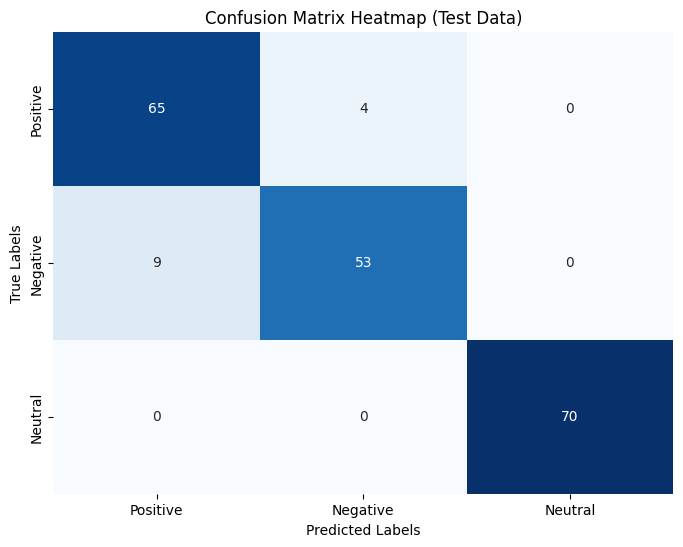

In [ ]:
#classification using randomforest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from scipy.sparse import vstack  # Import vstack for combining sparse matrices
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Feature extraction using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 features for efficiency
X = vectorizer.fit_transform(df_balanced['Preprocessed Article Content Without Stopwords'])

# Step 2: Preparing the target labels
y = df_balanced['Sentiment (VADER)']  # Replace with your sentiment column

# Step 3: Handle class imbalance using oversampling
oversampler = RandomOverSampler(random_state=42)
X_balanced, y_balanced = oversampler.fit_resample(X, y)

# Step 4: Split the balanced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Random Forest Classifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

# Step 6: Calculate predictions
y_train_pred = random_forest.predict(X_train)
y_test_pred = random_forest.predict(X_test)

# Step 7: Combine training and test data for overall accuracy
X_combined = vstack([X_train, X_test])  # Vertically stack feature matrices
y_combined = pd.concat([y_train, y_test])  # Combine labels
y_combined_pred = random_forest.predict(X_combined)

# Step 8: Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
overall_accuracy = accuracy_score(y_combined, y_combined_pred)

# Step 9: Print all accuracies
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# Step 10: Evaluate and visualize the confusion matrix (for test set)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix for Test Data
cm = confusion_matrix(y_test, y_test_pred, labels=y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique(), cbar=False)
plt.title("Confusion Matrix Heatmap (Test Data)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



In [ ]:
import joblib
# Assuming `random_forest` is your trained RandomForestClassifier
# and `vectorizer` is your trained TfidfVectorizer

# Save the Random Forest model
joblib.dump(random_forest, "random_forest_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer have been saved successfully.")
os.getcwd()

Model and vectorizer have been saved successfully.


'/content'